In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [25]:
import pandas as pd
 
FILE = "Individual AnnotationsORC.xlsx"
 
df = pd.read_excel(FILE, header=[0, 1])
 
 

In [26]:
# ── 2. Aplanar el MultiIndex de columnas ──────────────────────────────────────
df.columns = [
    f"{a}|{b}".strip() if not b.startswith("Unnamed") else a.strip()
    for a, b in df.columns
]
 
# La primera columna es el nombre del paper
df = df.rename(columns={df.columns[0]: "paper"})
df = df.dropna(subset=["paper"])          # elimina filas sin paper
df["paper"] = df["paper"].astype(str).str.strip()
df = df[df["paper"].str.match(r"^\d+\.")]  # solo filas que empiezan con número
 
print(f"Papers cargados: {len(df)}")
print("Columnas:", df.columns.tolist())

Papers cargados: 44
Columnas: ['paper', 'Lectura general', 'Arquitecturas de redes neuronales|ML', 'Arquitecturas de redes neuronales|Ventajas desventajas de ML', 'Arquitecturas de redes neuronales|¿Framework?', 'Modelación directa|Método estándar', 'Modelación directa|¿Cuál Framework?', 'Aplicación en problemas inversos|Datos utilizados', 'Dimensionalidad|Dimensiones', 'Dimensionalidad|¿Impacto de dimensionalidad?', 'Tipo de Ecuación|Ecuación', 'Tipo de Ecuación|¿Influencia y desempeño?', 'Integración ML y SNM', 'Problema Inverso', 'Research gaps', 'Análisis de resultados comparativos']


In [27]:
# ── 3. Separar columnas de texto y columnas categóricas ───────────────────────
# Todas las columnas menos 'paper' y 'Lectura general'
feature_cols = [c for c in df.columns if c != "paper"]
 
# Columnas cortas/categóricas (dimensiones, ecuación, framework, método, datos)
CAT_KEYWORDS = ["Dimensiones", "Ecuación", "Framework", "Método", "Datos"]
cat_cols  = [c for c in feature_cols if any(k in c for k in CAT_KEYWORDS)]
text_cols = [c for c in feature_cols if c not in cat_cols]
 
print(f"\nColumnas categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Columnas de texto ({len(text_cols)}): {text_cols}")


Columnas categóricas (7): ['Arquitecturas de redes neuronales|¿Framework?', 'Modelación directa|Método estándar', 'Modelación directa|¿Cuál Framework?', 'Aplicación en problemas inversos|Datos utilizados', 'Dimensionalidad|Dimensiones', 'Tipo de Ecuación|Ecuación', 'Tipo de Ecuación|¿Influencia y desempeño?']
Columnas de texto (8): ['Lectura general', 'Arquitecturas de redes neuronales|ML', 'Arquitecturas de redes neuronales|Ventajas desventajas de ML', 'Dimensionalidad|¿Impacto de dimensionalidad?', 'Integración ML y SNM', 'Problema Inverso', 'Research gaps', 'Análisis de resultados comparativos']


In [32]:
cat_cols

['Arquitecturas de redes neuronales|¿Framework?',
 'Modelación directa|Método estándar',
 'Modelación directa|¿Cuál Framework?',
 'Aplicación en problemas inversos|Datos utilizados',
 'Dimensionalidad|Dimensiones',
 'Tipo de Ecuación|Ecuación',
 'Tipo de Ecuación|¿Influencia y desempeño?']

In [28]:
# ── 4. Vectorizar texto con TF-IDF + SVD ─────────────────────────────────────
def clean(val):
    if pd.isna(val): return ""
    return str(val).lower().strip()
 
# Concatenar todo el texto de cada paper en un solo string
df["_texto"] = df[text_cols].applymap(clean).agg(" ".join, axis=1)
 
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)
X_text = tfidf.fit_transform(df["_texto"])
print(f"\nMatriz TF-IDF: {X_text.shape}")
 
# Reducir con SVD (LSA) a 30 dimensiones
n_components = min(30, X_text.shape[1] - 1, X_text.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_text_reduced = svd.fit_transform(X_text)
print(f"Varianza explicada por SVD: {svd.explained_variance_ratio_.sum():.1%}")


Matriz TF-IDF: (44, 500)
Varianza explicada por SVD: 82.9%


/tmp/ipykernel_5087/3494735432.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df["_texto"] = df[text_cols].applymap(clean).agg(" ".join, axis=1)


In [29]:
# ── 5. Vectorizar columnas categóricas con one-hot ────────────────────────────
cat_dummies = pd.get_dummies(
    df[cat_cols].applymap(clean).applymap(lambda x: x if x not in ["", "nan", "not reported"] else "NR"),
    prefix_sep="|"
).astype(float)
 
print(f"Columnas one-hot: {cat_dummies.shape[1]}")

Columnas one-hot: 142


/tmp/ipykernel_5087/3200093399.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[cat_cols].applymap(clean).applymap(lambda x: x if x not in ["", "nan", "not reported"] else "NR"),


In [30]:
# ── 6. Combinar: 60% texto, 40% categórico ───────────────────────────────────
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_text_s = scaler.fit_transform(X_text_reduced) * 0.6
X_cat_s   = scaler.fit_transform(cat_dummies)    * 0.4
 
X = np.hstack([X_text_s, X_cat_s])
print(f"\nMatriz final combinada: {X.shape}  ({len(df)} papers x {X.shape[1]} features)")
 
# Guardar para el paso 3
np.save("X_features.npy", X)
df[["paper"]].to_csv("paper_names.csv", index=False)
print("\n✓ Guardado: X_features.npy y paper_names.csv")
print("→ Listo para el Paso 3: reducción 2D y visualización")


Matriz final combinada: (44, 172)  (44 papers x 172 features)

✓ Guardado: X_features.npy y paper_names.csv
→ Listo para el Paso 3: reducción 2D y visualización


Reducción con UMAP: (44, 2)


/home/orincon/miniconda3/envs/ml-seismic-waves-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


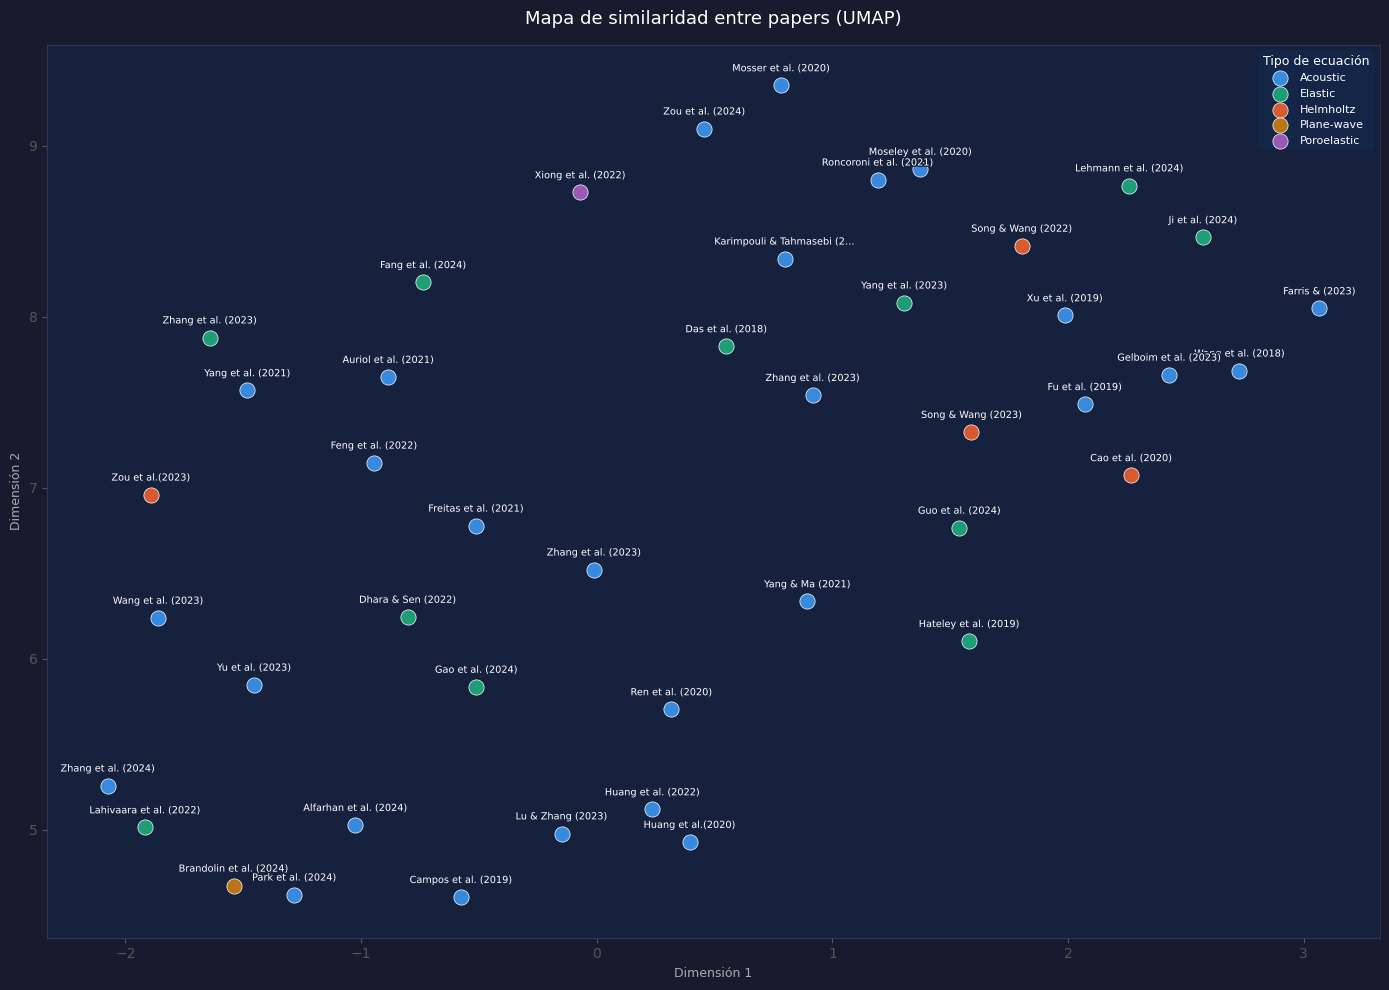

✓ Guardado: mapa_similaridad.png


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.manifold import TSNE

# ── 1. Cargar datos del paso 2 ────────────────────────────────────────────────
X      = np.load("X_features.npy")
papers = pd.read_csv("paper_names.csv")["paper"].tolist()

# Etiqueta corta: "Moseley et al. (2020)"
labels = [p.split(". ", 1)[1] if ". " in p else p for p in papers]

# ── 2. Reducción 2D con t-SNE ─────────────────────────────────────────────────
# Intentar UMAP primero (mejor para clusters), caer a t-SNE si no está instalado
try:
    from umap import UMAP
    reducer = UMAP(n_components=2, n_neighbors=6, min_dist=0.25,
                   metric="cosine", random_state=42)
    method_name = "UMAP"
except ImportError:
    perp = min(10, len(X) - 1)
    reducer = TSNE(n_components=2, perplexity=perp,
                   metric="cosine", random_state=42, n_iter=2000)
    method_name = "t-SNE"

coords = reducer.fit_transform(X)
print(f"Reducción con {method_name}: {coords.shape}")

# ── 3. Colores por tipo de ecuación ──────────────────────────────────────────
FILE = "Individual AnnotationsORC.xlsx"
df   = pd.read_excel(FILE, header=[0, 1])
df.columns = [
    f"{a}|{b}".strip() if not b.startswith("Unnamed") else a.strip()
    for a, b in df.columns
]
df = df.rename(columns={df.columns[0]: "paper"})
df = df.dropna(subset=["paper"])
df = df[df["paper"].astype(str).str.match(r"^\d+\.")]

# Buscar columna de ecuación
eq_col = [c for c in df.columns if "Ecuación" in c or "Ecuacion" in c]
eq_col = eq_col[0] if eq_col else None

if eq_col:
    def norm_eq(v):
        v = str(v).lower()
        if "elastic" in v and "helmholtz" in v: return "Elastic + Helmholtz"
        if "elastic" in v:   return "Elastic"
        if "helmholtz" in v: return "Helmholtz"
        if "poro" in v or "biot" in v: return "Poroelastic"
        if "plane" in v:     return "Plane-wave"
        return "Acoustic"
    eq_labels = df[eq_col].apply(norm_eq).tolist()
else:
    eq_labels = ["Unknown"] * len(labels)

eq_types   = sorted(set(eq_labels))
palette    = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517", "#9B59B6", "#E24B4A"]
color_map  = {eq: palette[i % len(palette)] for i, eq in enumerate(eq_types)}
colors     = [color_map[e] for e in eq_labels]

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#16213e")

# Puntos
for eq in eq_types:
    idx = [i for i, e in enumerate(eq_labels) if e == eq]
    ax.scatter(coords[idx, 0], coords[idx, 1],
               c=color_map[eq], s=120, zorder=3,
               label=eq, edgecolors="white", linewidths=0.5)

# Etiquetas con borde para legibilidad
for i, label in enumerate(labels):
    # Acortar si es muy largo
    short = label if len(label) < 28 else label[:25] + "…"
    txt = ax.text(
        coords[i, 0], coords[i, 1] + 0.015 * (coords[:, 1].max() - coords[:, 1].min()),
        short, fontsize=7, color="white", ha="center", va="bottom", zorder=4
    )
    txt.set_path_effects([
        pe.Stroke(linewidth=2, foreground="#16213e"),
        pe.Normal()
    ])

# Leyenda y estilo
legend = ax.legend(title="Tipo de ecuación", framealpha=0.3,
                   facecolor="#0f3460", edgecolor="none",
                   labelcolor="white", title_fontsize=9, fontsize=8)
legend.get_title().set_color("white")

ax.set_title(f"Mapa de similaridad entre papers ({method_name})",
             color="white", fontsize=13, pad=15)
ax.set_xlabel("Dimensión 1", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Dimensión 2", color="#aaaaaa", fontsize=9)
ax.tick_params(colors="#555555")
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

plt.tight_layout()
plt.savefig("mapa_similaridad.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Guardado: mapa_similaridad.png")
